In [1]:
!python -V

Python 3.10.20


In [2]:
!where python

/Users/cyberdemon/.pyenv/versions/3.10.20/bin/python
/Users/cyberdemon/.pyenv/shims/python


# Этап 1. Загрузка и предобработка данных

In [3]:
import torch
from torchvision.datasets import ImageFolder

dataset_path = './dataset/ogyeiv2'

train_dataset = ImageFolder(f'{dataset_path}/train')
test_dataset = ImageFolder(f'{dataset_path}/test')

acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg


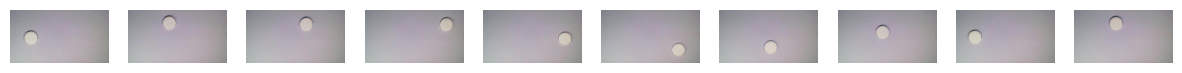

In [4]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = train_dataset[index]
    print(train_dataset.classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image)
    plt.axis('off')


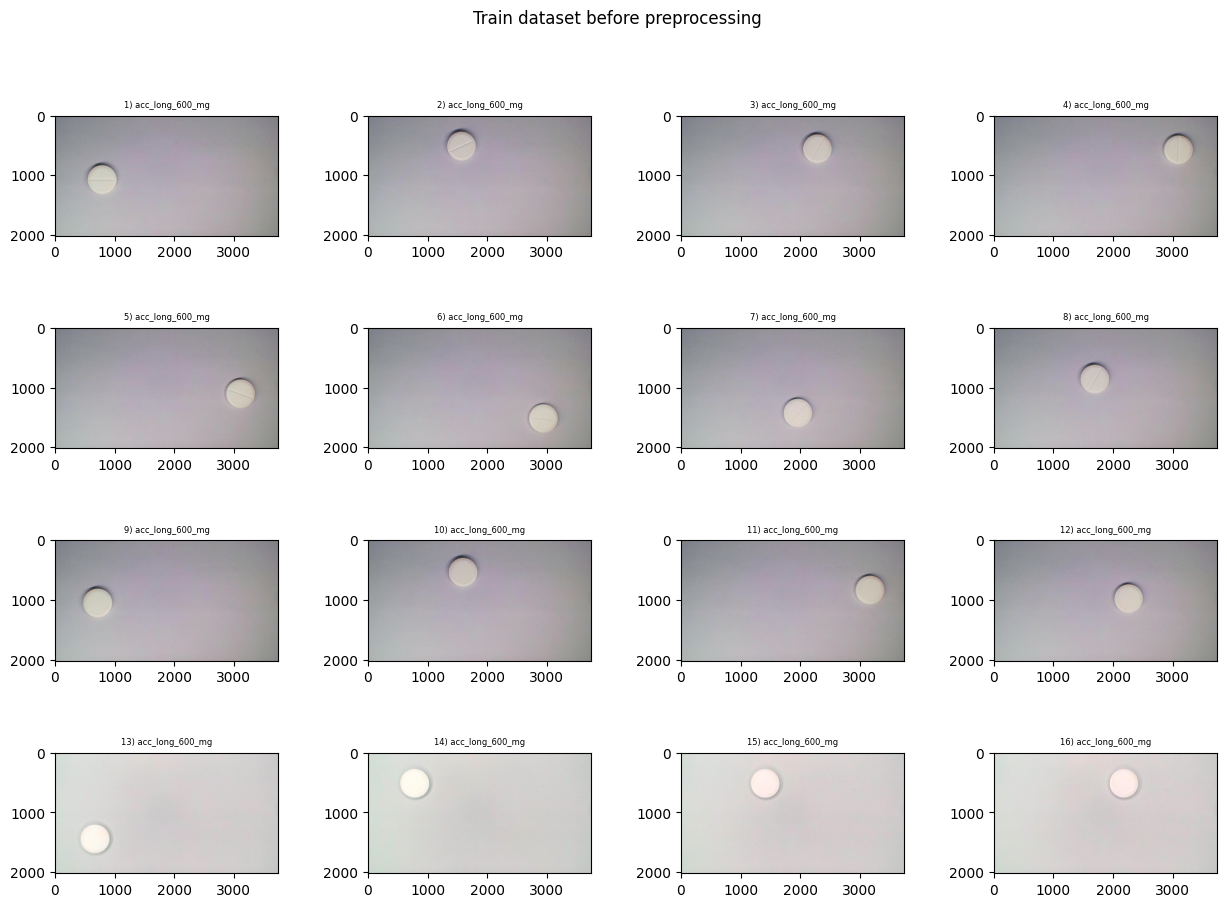

In [5]:
fig, axis = plt.subplots(4, 4, figsize=(15,10), gridspec_kw={'wspace': 0.4, 'hspace': 0.6})

for i, ax in enumerate(axis.flat, start=1):
    image, label = train_dataset[i]
    
    ax.axis('on')
    ax.imshow(image)
    ax.set_title(f'{i}) {train_dataset.classes[label]}', fontsize=6)

plt.suptitle('Train dataset before preprocessing')
plt.show()

acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
advil_ultra_forte
advil_ultra_forte
advil_ultra_forte
advil_ultra_forte
advil_ultra_forte


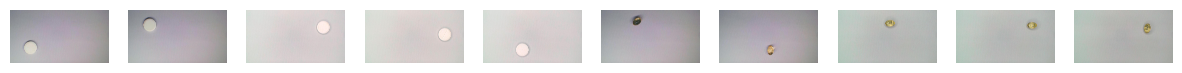

In [6]:
fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = test_dataset[index]
    print(test_dataset.classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image)
    plt.axis('off')

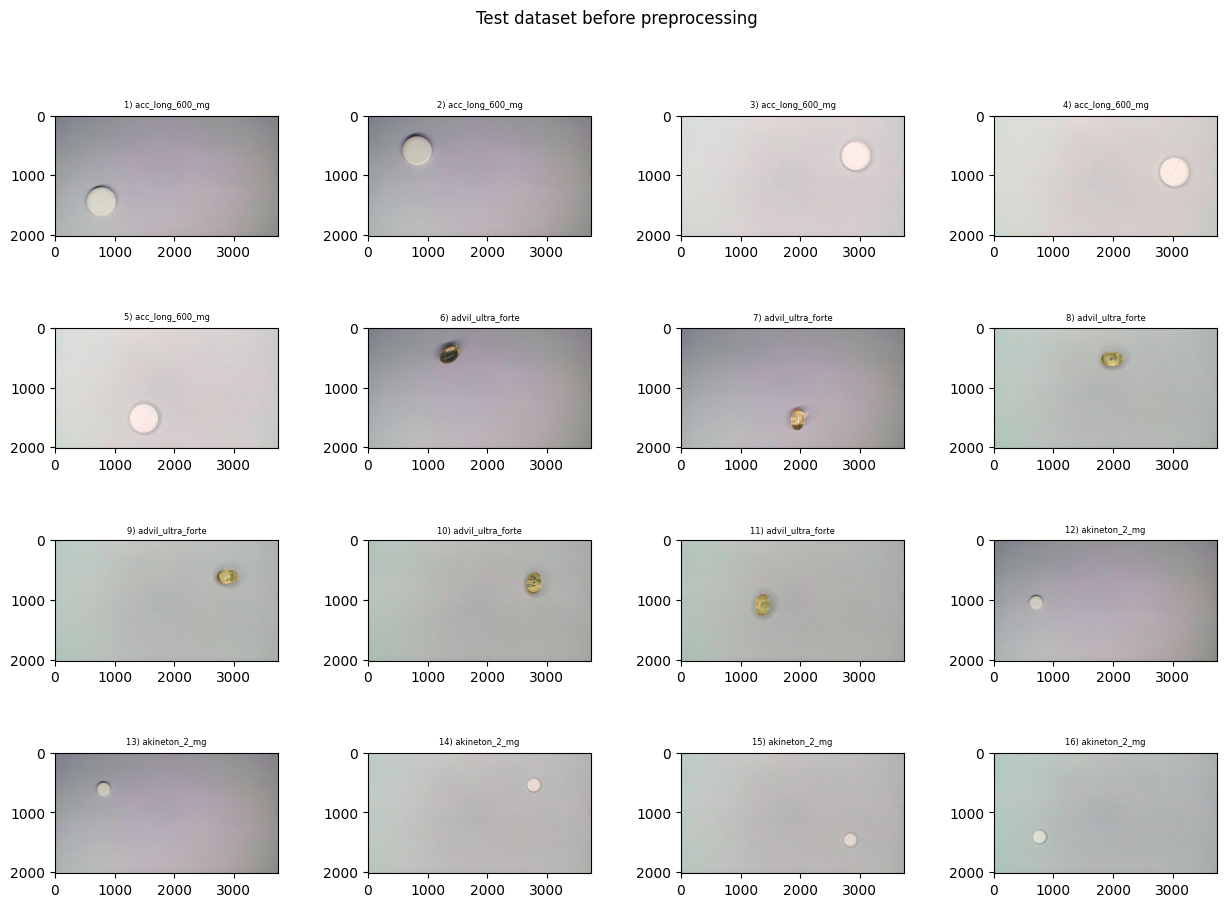

In [7]:
fig, axis = plt.subplots(4, 4, figsize=(15,10), gridspec_kw={'wspace': 0.4, 'hspace': 0.6})

for i, ax in enumerate(axis.flat, start=1):
    image, label = test_dataset[i]
    
    ax.axis('on')
    ax.imshow(image)
    ax.set_title(f'{i}) {test_dataset.classes[label]}', fontsize=6)

plt.suptitle('Test dataset before preprocessing')
plt.show()

In [8]:
from torchvision.transforms import Compose, Resize, Pad, ToTensor, Normalize
from torchvision.transforms.v2 import RandomHorizontalFlip, RandomVerticalFlip, RandomRotation

train_transforms = Compose([
    # RandomHorizontalFlip(p=0.2),
    # RandomVerticalFlip(p=0.2),
    # RandomRotation([-5, 5], fill=255),
    # Pad((0, 500, 0, 500), fill=255),
    Resize((224, 224)),
    ToTensor(),
    Normalize((0.5), (0.5)),
])

test_transforms = Compose([
    # Pad((0, 500, 0, 500), fill=255),
    Resize((224, 224)),
    ToTensor(),
    Normalize((0.5), (0.5)),
])

In [9]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
  def __init__(self, dataset, transforms):
    super().__init__()
    self.dataset = dataset
    self.transforms = transforms
    self.classes = dataset.classes

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    x, y = self.dataset[idx]
    return self.transforms(x), y

In [10]:
train_dataset = TransformDataset(train_dataset, train_transforms)
val_dataset = TransformDataset(test_dataset, test_transforms)

In [11]:
print("Количество изображений в train:", len(train_dataset))
print("Количество изображений в val:", len(val_dataset))

print("Количество классовв train:", len(train_dataset.classes))
print("Количество классов в val:", len(test_dataset.classes))

print("Список классовв train:", train_dataset.classes)
print("Список классов в val:", test_dataset.classes)

Количество изображений в train: 2352
Количество изображений в val: 504
Количество классовв train: 84
Количество классов в val: 84
Список классовв train: ['acc_long_600_mg', 'advil_ultra_forte', 'akineton_2_mg', 'algoflex_forte_dolo_400_mg', 'algoflex_rapid_400_mg', 'algopyrin_500_mg', 'ambroxol_egis_30_mg', 'apranax_550_mg', 'aspirin_ultra_500_mg', 'atoris_20_mg', 'atorvastatin_teva_20_mg', 'betaloc_50_mg', 'bila_git', 'c_vitamin_teva_500_mg', 'calci_kid', 'cataflam_50_mg', 'cataflam_dolo_25_mg', 'cetirizin_10_mg', 'cold_fx', 'coldrex', 'concor_10_mg', 'concor_5_mg', 'condrosulf_800_mg', 'controloc_20_mg', 'covercard_plus_10_mg_2_5_mg_5_mg', 'coverex_4_mg', 'diclopram_75-mg_20-mg', 'dorithricin_mentol', 'dulsevia_60_mg', 'enterol_250_mg', 'favipiravir_meditop_200_mg', 'ibumax_400_mg', 'jutavit_c_vitamin', 'jutavit_cink', 'kalcium_magnezium_cink', 'kalium_r', 'koleszterin_kontroll', 'lactamed', 'lactiv_plus', 'laresin_10_mg', 'letrox_50_mikrogramm', 'lordestin_5_mg', 'merckformin_xr_100

In [12]:
img, y = train_dataset[0]

print('Shape:', img.shape)
print('Class id:', y)
print('Class name:', train_dataset.classes[y])

Shape: torch.Size([3, 224, 224])
Class id: 0
Class name: acc_long_600_mg


In [13]:
img, y = val_dataset[0]

print('Shape:', img.shape)
print('Class id:', y)
print('Class name:', val_dataset.classes[y])

Shape: torch.Size([3, 224, 224])
Class id: 0
Class name: acc_long_600_mg


torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


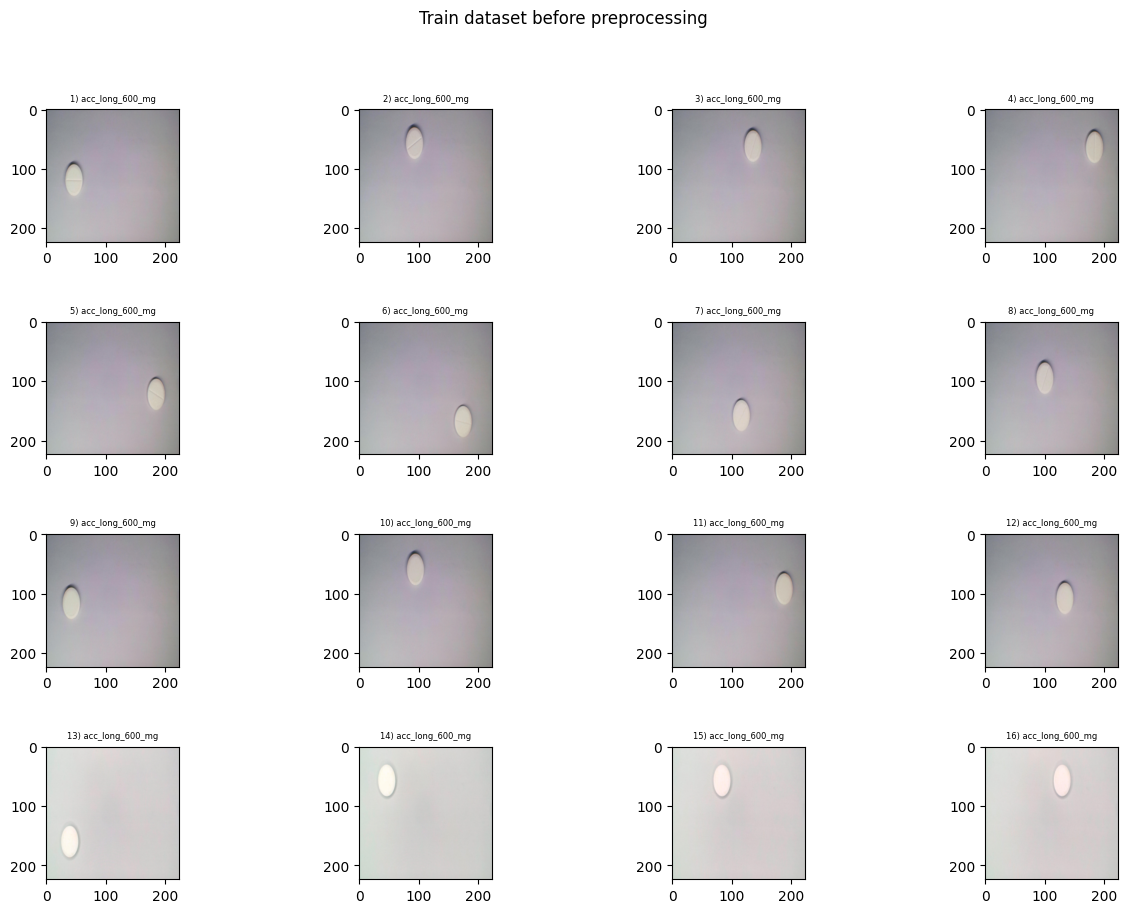

In [14]:
fig, axis = plt.subplots(4, 4, figsize=(15,10), gridspec_kw={'wspace': 0.4, 'hspace': 0.6})

for i, ax in enumerate(axis.flat, start=1):
    image, label = train_dataset[i]

    print(image.shape)
    
    ax.axis('on')
    img = image.cpu().permute(1,2,0) * 0.5 + 0.5
    ax.imshow(img)
    ax.set_title(f'{i}) {train_dataset.classes[label]}', fontsize=6)

plt.suptitle('Train dataset before preprocessing')
plt.show()

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


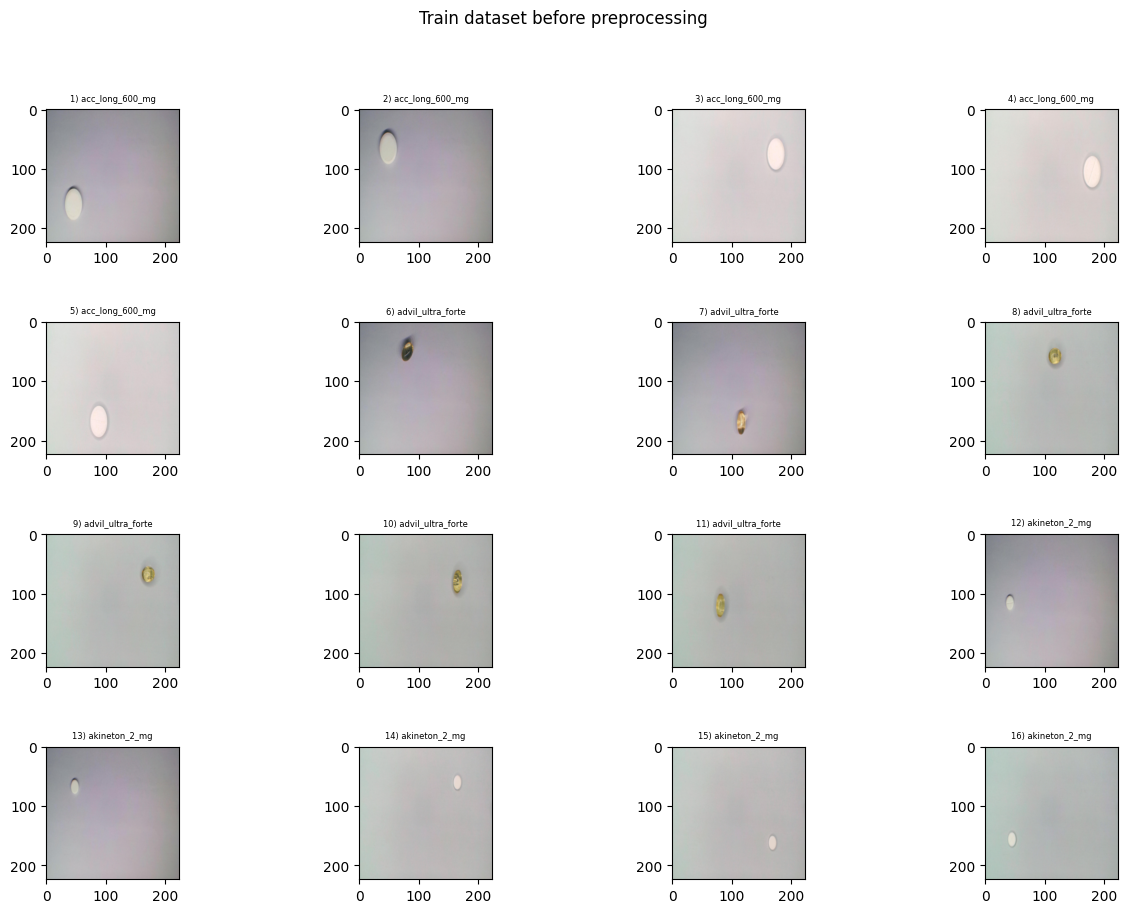

In [15]:
fig, axis = plt.subplots(4, 4, figsize=(15,10), gridspec_kw={'wspace': 0.4, 'hspace': 0.6})

for i, ax in enumerate(axis.flat, start=1):
    image, label = val_dataset[i]

    print(image.shape)
    
    ax.axis('on')
    img = image.cpu().permute(1,2,0) * 0.5 + 0.5
    ax.imshow(img)
    ax.set_title(f'{i}) {val_dataset.classes[label]}', fontsize=6)

plt.suptitle('Train dataset before preprocessing')
plt.show()

In [16]:
import torch
import random
import numpy as np

def seed_worker(worker_id):
    worker_seed = 42 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g, worker_init_fn=seed_worker)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [17]:
print('Размер батча train:', len(train_loader))
print('Размер батча train:', len(val_loader))

Размер батча train: 74
Размер батча train: 16


In [18]:
for batch_index, data in enumerate(train_loader, start=1):
    inputs, labels = data
    print(f'Batch {batch_index}')

    for i in labels.tolist():
        print(i, train_dataset.classes[i])
    
    break

Batch 1
30 favipiravir_meditop_200_mg
16 cataflam_dolo_25_mg
45 mezym_forte_10_000_egyseg
42 merckformin_xr_1000_mg
46 milgamma
78 verospiron_25_mg
81 voltaren_dolo_rapid_25_mg
56 novo_c_plus
42 merckformin_xr_1000_mg
52 neo_citran
73 tritace_5_mg
9 atoris_20_mg
25 coverex_4_mg
31 ibumax_400_mg
3 algoflex_forte_dolo_400_mg
32 jutavit_c_vitamin
45 mezym_forte_10_000_egyseg
35 kalium_r
6 ambroxol_egis_30_mg
54 nolpaza_20_mg
7 apranax_550_mg
54 nolpaza_20_mg
41 lordestin_5_mg
50 naturland_d_vitamin_forte
7 apranax_550_mg
31 ibumax_400_mg
38 lactiv_plus
17 cetirizin_10_mg
44 metothyrin_10_mg
23 controloc_20_mg
12 bila_git
66 sinupret_forte


In [19]:
for batch_index, data in enumerate(val_loader, start=1):
    inputs, labels = data
    print(f'Batch {batch_index}')

    for i in labels.tolist():
        print(i, val_dataset.classes[i])
    
    break

Batch 1
0 acc_long_600_mg
0 acc_long_600_mg
0 acc_long_600_mg
0 acc_long_600_mg
0 acc_long_600_mg
0 acc_long_600_mg
1 advil_ultra_forte
1 advil_ultra_forte
1 advil_ultra_forte
1 advil_ultra_forte
1 advil_ultra_forte
1 advil_ultra_forte
2 akineton_2_mg
2 akineton_2_mg
2 akineton_2_mg
2 akineton_2_mg
2 akineton_2_mg
2 akineton_2_mg
3 algoflex_forte_dolo_400_mg
3 algoflex_forte_dolo_400_mg
3 algoflex_forte_dolo_400_mg
3 algoflex_forte_dolo_400_mg
3 algoflex_forte_dolo_400_mg
3 algoflex_forte_dolo_400_mg
4 algoflex_rapid_400_mg
4 algoflex_rapid_400_mg
4 algoflex_rapid_400_mg
4 algoflex_rapid_400_mg
4 algoflex_rapid_400_mg
4 algoflex_rapid_400_mg
5 algopyrin_500_mg
5 algopyrin_500_mg
